In [1]:
import os
nthreads = 1
os.environ["OMP_NUM_THREADS"] = str(nthreads)
os.environ["OPENBLAS_NUM_THREADS"] = str(nthreads)
os.environ["MKL_NUM_THREADS"] = str(nthreads)

In [16]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import inferagni as ia
import pandas as pd
from cmcrameri import cm
from copy import deepcopy


from inferagni.plot import truth_color, samples_color, DPI
from inferagni.util import varprops

In [9]:
%config InlineBackend.figure_format = 'retina'

In [10]:
cases = {"inst":None, "wo_inst":None}

outdir = "output/"

for k in cases.keys():
    outdir_planet = f"{outdir}/pi_Men_c({k})/"
    print(outdir_planet)

    samps = pd.read_csv(outdir_planet+"result.csv",skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(outdir_planet+"truth.csv" ,skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # get last samples from samps
    end_frac = 0.01
    nsamp = int(len(samps)*(1-end_frac))
    samps = samps.iloc[-nsamp:]

    cases[k] = {"samps":samps, "truth":truth}

    print(truth.keys())
    print(samps.keys())

output//pi_Men_c(inst)/
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2', 'μ_phot', 'log_vmr_CO2', 'log_vmr_CO',
       'log_vmr_H2O', 'r_phot', 't_surf', 'log_vmr_H2S'],
      dtype='str')
output//pi_Men_c(wo_inst)/
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2O', 'log_vmr_CO2', 'log_vmr_H2', 'log_vmr_CO',
       'μ_phot', 't_surf', 'log_vmr_H2S', 'r_phot'],
      dtype='str')


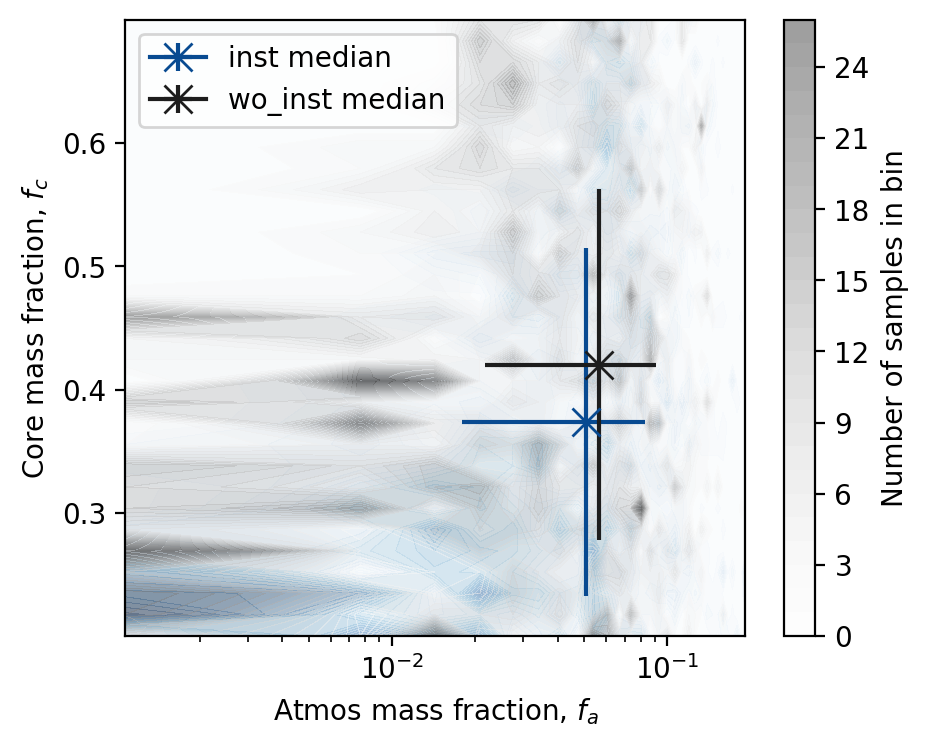

In [104]:
fig,ax = plt.subplots(1,1, figsize=(5,4))

xkey = "frac_atm"
ykey = "frac_core"

nbins = 30
hist = {}
counts_max = 1
xmin, xmax = np.inf, -np.inf
ymin, ymax = np.inf, -np.inf
for k in cases.keys():
    counts, xbins, ybins = np.histogram2d(cases[k]["samps"][xkey] * varprops[xkey].scale,
                                          cases[k]["samps"][ykey] * varprops[ykey].scale,
                                          bins=nbins)
    hist[k] = (counts, xbins, ybins)
    counts_max = max(counts_max, np.amax(counts))
    xmin = min(xmin, np.amin(xbins))
    xmax = max(xmax, np.amax(xbins))
    ymin = min(ymin, np.amin(ybins))
    ymax = max(ymax, np.amax(ybins))

for (c,k) in zip(['Blues','Greys'],cases.keys()):

    cmap = plt.get_cmap(c)

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    # counts, xbins, ybins, sm = ax.hist2d(x,y, cmap=cmap, alpha=0.3, bins=nbins, vmin=0, vmax=counts_max)

    sm = ax.contourf(hist[k][0].T, levels=np.shape(counts)[1],  vmin=0, vmax=counts_max,
               extent=[xmin, xmax, ymin, ymax], cmap=cmap, alpha=0.5)

    ax.errorbar(np.median(x), np.median(y), xerr=np.std(x), yerr=np.std(y),
                color=cmap(0.9), marker='x', markersize=10, label=f"{k} median")

cbar = fig.colorbar(sm, ax=ax, label="Number of samples in bin")
# cbar.ax.set_ylim(0, counts_max)

ax.set_ylabel(varprops[ykey].label)
ax.set_xlabel(varprops[xkey].label)
if varprops[xkey].log:
    ax.set_xscale("log")
if varprops[ykey].log:
    ax.set_yscale("log")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.legend(loc='upper left')

fig.savefig(outdir_planet+"inst_vs_noinst.png",  dpi=DPI, bbox_inches="tight")
plt.show()